# Análisis de Mapas del Modelo nnELM

Notebook de verificación y análisis exploratorio de los mapas generados por el modelo
antes de proceder a la extracción de features para EEG.

---

## Qué mapas tenemos

### Mapas estáticos (independientes de la fijación)
| Mapa | Ruta | Descripción |
|------|------|-------------|
| Saliencia | `Results/saliency_maps/HSUBANOTT/deepgaze/` | Prior bottom-up (DeepGaze II). Un archivo `.jpg` por imagen. |
| Similitud | `Results/target_similarity_maps/HSUBANOTT/Ivsnresnext/` | Evidencia visual top-down (ResNeXt101). Un archivo `.png` por par (imagen, target). |

### Mapas dinámicos (fijación a fijación, en scanpaths humanos)
Almacenados en `Human_Maps/HSUBANOTT/{subject_id}/{image}.npz`

| Campo | Shape | Descripción |
|-------|-------|-------------|
| `visual_evidence` | `(n_fix, 24, 32)` | Evidencia acumulada W en cada fijación |
| `posterior` | `(n_fix, 24, 32)` | Creencia bayesiana posterior actualizada |
| `entropy_map` | `(n_fix, 24, 32)` | Contribución por celda: `-p·log(p)` |
| `expected_ig_map` | `(n_fix, 24, 32)` | EIG si la próxima fijación fuera cada celda (Eq. 6 del paper) |
| `fixations_y` | `(n_fix,)` | Fila en la grilla (coord Y, 0–23) |
| `fixations_x` | `(n_fix,)` | Columna en la grilla (coord X, 0–31) |
| `memory_set` | `list[str]` | Objetos del memory set |
| `target_stim` | `str` | Target buscado |
| `target_found` | `bool` | Si el sujeto encontró el target |

### Cómo cargar los mapas
```python
import Utils.map_loader as ml

# Mapa de saliencia (full-res o redimensionado a la grilla 24x32)
saliencia = ml.cargar_mapa_saliencia('cmp_building_014_person_007.jpg', como_grilla=True)

# Mapa de similitud
similitud = ml.cargar_mapa_similitud('cmp_building_014_person_007.jpg', 'person385.png')

# Mapas dinámicos de un sujeto/imagen
data = ml.cargar_mapas_humanos('S101', 'cmp_building_014_person_007.jpg')
print(data['posterior'].shape)        # (n_fix, 24, 32)
print(data['expected_ig_map'].shape)  # (n_fix, 24, 32)
print(data['target_found'])           # True / False

# Features escalares por fijación
entropia = ml.entropia_escalar(data)   # (n_fix,)
eig_fix  = ml.eig_en_fijacion(data)   # (n_fix,) — EIG en la celda fijada
eig_max  = ml.eig_maximo(data)        # (n_fix,) — EIG óptimo del modelo
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import random
import warnings
warnings.filterwarnings('ignore')

import Utils.map_loader as ml

# Reproducibilidad en selecciones aleatorias
random.seed(42)
np.random.seed(42)

---
## 1. Disponibilidad de Datos

In [3]:
sujetos = ml.listar_sujetos()
print(f'Sujetos con mapas extraídos: {len(sujetos)}')
print(sujetos[:5], '...')

# Imágenes de un sujeto de ejemplo
SUJETO_EJEMPLO = sujetos[0]
imagenes = ml.listar_imagenes(SUJETO_EJEMPLO)
print(f'\nImágenes para {SUJETO_EJEMPLO}: {len(imagenes)}')
print(imagenes[:3], '...')

Sujetos con mapas extraídos: 44
['S101', 'S102', 'S103', 'S105', 'S106'] ...

Imágenes para S101: 102
['cmp_africansavanna_003_wildanimals_003.jpg', 'cmp_beach_002_person_002.jpg', 'cmp_beach_003_bird_001.jpg'] ...


In [4]:
# Resumen de disponibilidad por sujeto
df_disp = ml.resumen_disponibilidad()
display(df_disp.describe().round(1))
display(df_disp.head(10))

,n_imagenes,n_fijaciones_total,n_fijaciones_media
count,44.0,44.0,44.0
mean,101.0,979.3,9.7
std,1.9,113.4,1.1
min,90.0,735.0,7.4
25%,101.0,919.8,9.1
50%,101.0,969.5,9.5
75%,102.0,1027.2,10.2
max,102.0,1314.0,13.0


,subject_id,n_imagenes,n_fijaciones_total,n_fijaciones_media
0,S101,102,1228,12.0
1,S102,102,904,8.9
2,S103,99,735,7.4
3,S105,102,1025,10.0
4,S106,102,1077,10.6
5,S107,102,931,9.1
6,S108,90,1058,11.8
7,S109,102,1017,10.0
8,S110,102,931,9.1
9,S111,100,1042,10.4


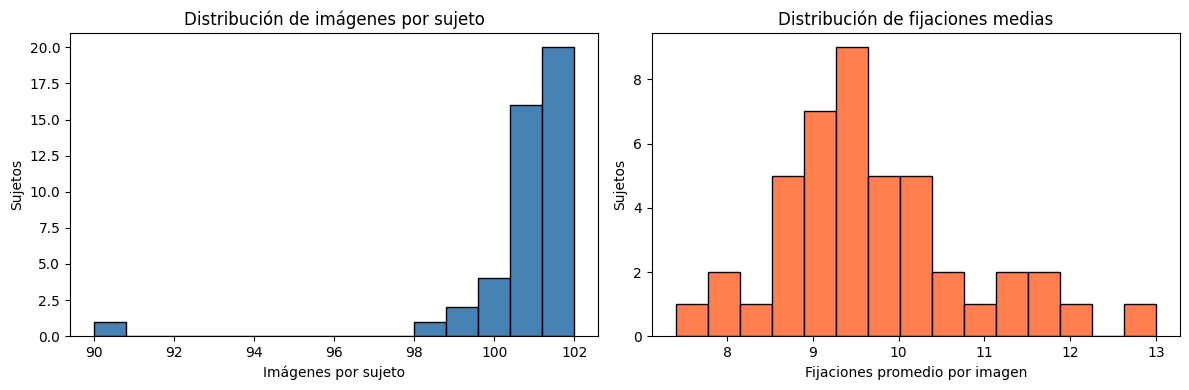

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_disp['n_imagenes'], bins=15, edgecolor='k', color='steelblue')
axes[0].set_xlabel('Imágenes por sujeto')
axes[0].set_ylabel('Sujetos')
axes[0].set_title('Distribución de imágenes por sujeto')

axes[1].hist(df_disp['n_fijaciones_media'], bins=15, edgecolor='k', color='coral')
axes[1].set_xlabel('Fijaciones promedio por imagen')
axes[1].set_ylabel('Sujetos')
axes[1].set_title('Distribución de fijaciones medias')

plt.tight_layout()
plt.show()

---
## 2. Mapas Estáticos

In [12]:
# Seleccionar una imagen de ejemplo
IMAGEN = imagenes[3]
print('Imagen seleccionada:', IMAGEN)

# Cargar mapas estáticos a resolución completa
img_orig     = ml.cargar_imagen_original(IMAGEN)
mapa_sal     = ml.cargar_mapa_saliencia(IMAGEN)

print(f'Imagen original:  shape={img_orig.shape}')
print(f'Mapa saliencia:   shape={mapa_sal.shape}, min={mapa_sal.min():.3f}, max={mapa_sal.max():.3f}')

Imagen seleccionada: cmp_building_003_person_001.jpg
Imagen original:  shape=(1024, 1280, 3)
Mapa saliencia:   shape=(768, 1024), min=0.000, max=1.000


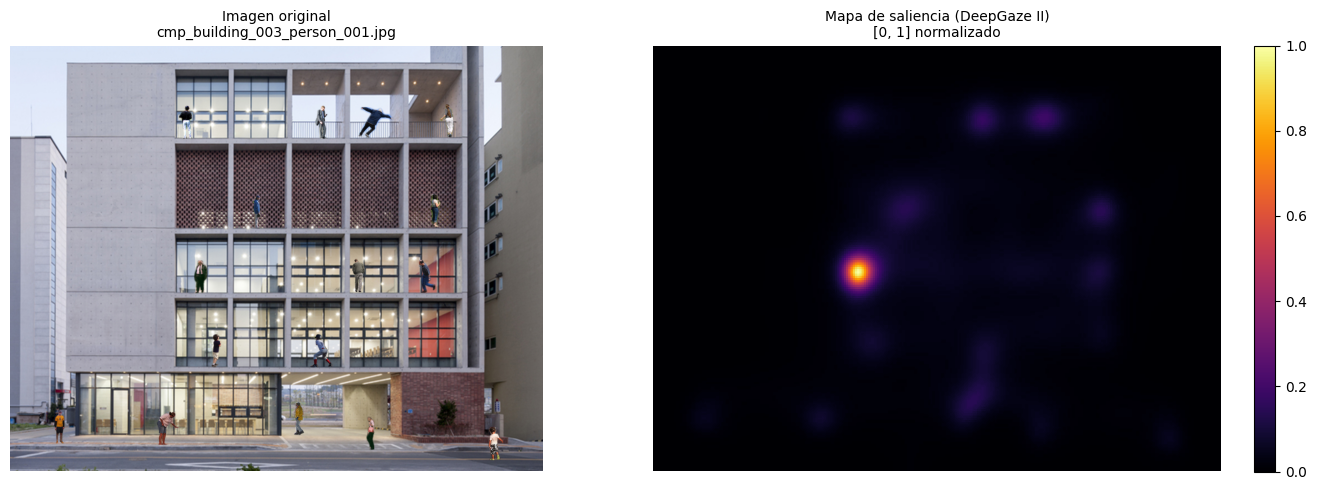

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(img_orig)
axes[0].set_title(f'Imagen original\n{IMAGEN}', fontsize=10)
axes[0].axis('off')

im = axes[1].imshow(mapa_sal, cmap='inferno')
plt.colorbar(im, ax=axes[1], fraction=0.046)
axes[1].set_title('Mapa de saliencia (DeepGaze II)\n[0, 1] normalizado', fontsize=10)
axes[1].axis('off')

plt.tight_layout()
plt.show()

Target: stm_building_003_person_001_013.png
Memory set: ['stm_building_003_person_001_020.png', 'stm_building_003_person_001_013.png']
Target found: True


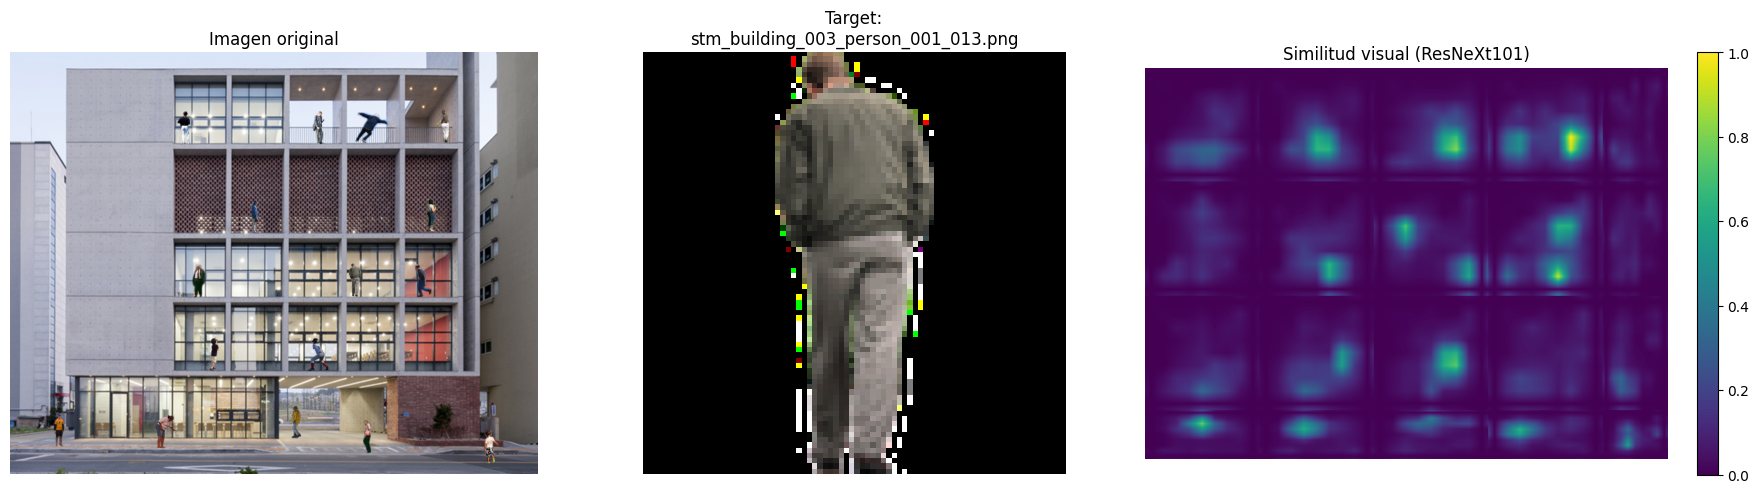

In [15]:
# Mapa de similitud: cargar datos dinámicos primero para obtener el target
data_ej = ml.cargar_mapas_humanos(SUJETO_EJEMPLO, IMAGEN)
TARGET  = data_ej['target_stim']
print('Target:', TARGET)
print('Memory set:', data_ej['memory_set'])
print('Target found:', data_ej['target_found'])

if ml.mapa_similitud_existe(IMAGEN, TARGET):
    mapa_sim   = ml.cargar_mapa_similitud(IMAGEN, TARGET)
    img_target = ml.cargar_imagen_target(TARGET)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].imshow(img_orig);    axes[0].set_title('Imagen original'); axes[0].axis('off')
    axes[1].imshow(img_target);  axes[1].set_title(f'Target:\n{TARGET}'); axes[1].axis('off')
    im = axes[2].imshow(mapa_sim, cmap='viridis')
    plt.colorbar(im, ax=axes[2], fraction=0.046)
    axes[2].set_title('Similitud visual (ResNeXt101)'); axes[2].axis('off')
    plt.tight_layout(); plt.show()
else:
    print(f'Mapa de similitud no encontrado para {IMAGEN} / {TARGET}')

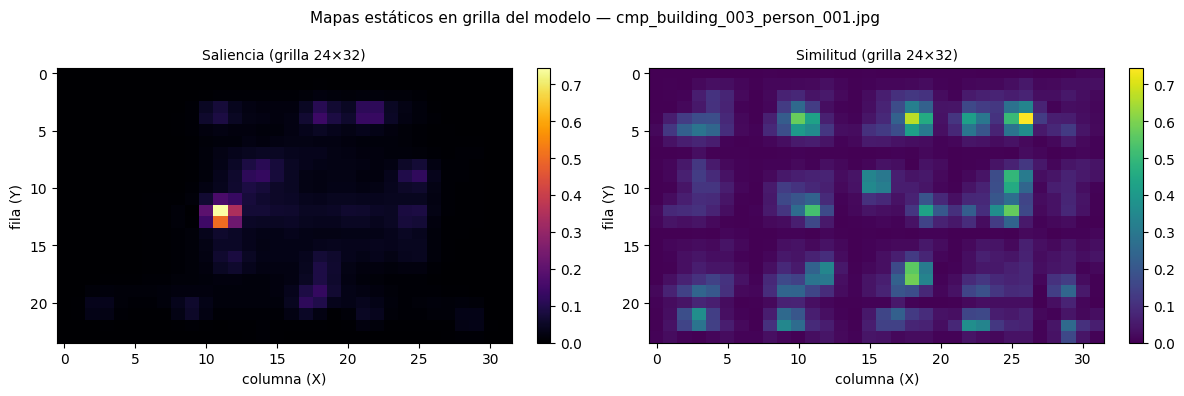

In [16]:
# Comparativa completa en la grilla del modelo (24×32)
sal_grid = ml.cargar_mapa_saliencia(IMAGEN, como_grilla=True)
sim_grid = ml.cargar_mapa_similitud(IMAGEN, TARGET, como_grilla=True) \
           if ml.mapa_similitud_existe(IMAGEN, TARGET) else None

mapas = [('Saliencia (grilla 24×32)', sal_grid, 'inferno'),
         ('Similitud (grilla 24×32)', sim_grid, 'viridis')]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (titulo, mapa, cmap) in zip(axes, mapas):
    if mapa is not None:
        im = ax.imshow(mapa, cmap=cmap, aspect='auto')
        plt.colorbar(im, ax=ax, fraction=0.046)
    else:
        ax.text(0.5, 0.5, 'No disponible', ha='center', va='center')
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel('columna (X)')
    ax.set_ylabel('fila (Y)')

plt.suptitle(f'Mapas estáticos en grilla del modelo — {IMAGEN}', fontsize=11)
plt.tight_layout()
plt.show()

---
## 3. Mapas Dinámicos — Estructura y Metadatos

In [17]:
# data_ej ya cargado arriba (SUJETO_EJEMPLO, IMAGEN)
n_fix = data_ej['posterior'].shape[0]

print('=== Metadatos del trial ===')
print(f'  Sujeto       : {SUJETO_EJEMPLO}')
print(f'  Imagen       : {IMAGEN}')
print(f'  Memory set   : {data_ej["memory_set"]}')
print(f'  Target stim  : {data_ej["target_stim"]}')
print(f'  Target found : {data_ej["target_found"]}')
print()
print('=== Arrays disponibles ===')
for k, v in data_ej.items():
    if isinstance(v, np.ndarray):
        print(f'  {k:<20} shape={v.shape}, dtype={v.dtype}')
    else:
        print(f'  {k:<20} {type(v).__name__} = {v}')

=== Metadatos del trial ===
  Sujeto       : S101
  Imagen       : cmp_building_003_person_001.jpg
  Memory set   : ['stm_building_003_person_001_020.png', 'stm_building_003_person_001_013.png']
  Target stim  : stm_building_003_person_001_013.png
  Target found : True

=== Arrays disponibles ===
  visual_evidence      shape=(19, 24, 32), dtype=float32
  posterior            shape=(19, 24, 32), dtype=float32
  entropy_map          shape=(19, 24, 32), dtype=float32
  fixations_y          shape=(19,), dtype=int16
  fixations_x          shape=(19,), dtype=int16
  memory_set           list = ['stm_building_003_person_001_020.png', 'stm_building_003_person_001_013.png']
  target_stim          str = stm_building_003_person_001_013.png
  target_found         bool = True


In [18]:
# Estadísticas básicas de los mapas dinámicos
for nombre, campo in [('visual_evidence', data_ej['visual_evidence']),
                      ('posterior',        data_ej['posterior']),
                      ('entropy_map',      data_ej['entropy_map']),
                      ('expected_ig_map',  data_ej['expected_ig_map'])]:
    if campo is not None:
        print(f'{nombre}: min={campo.min():.4f}  mean={campo.mean():.4f}  '
              f'max={campo.max():.4f}  NaNs={np.isnan(campo).sum()}')
    else:
        print(f'{nombre}: no disponible (archivo viejo)')

print()
print('Entropía escalar por fijación:', ml.entropia_escalar(data_ej).round(3))
print('EIG en fijación:              ', ml.eig_en_fijacion(data_ej).round(4))
print('EIG máximo (sácada óptima):   ', ml.eig_maximo(data_ej).round(4))
print('Concentración (max posterior):', ml.concentracion_posterior(data_ej).round(4))
print('Fijaciones Y:', data_ej['fixations_y'])
print('Fijaciones X:', data_ej['fixations_x'])

visual_evidence: min=-6.0208  mean=-0.0357  max=2.9298  NaNs=0
posterior: min=0.0000  mean=0.0013  max=0.0600  NaNs=0
entropy_map: min=0.0000  mean=0.0082  max=0.1688  NaNs=0

Entropía escalar por fijación: [5.903 5.922 6.149 6.132 6.165 6.265 6.346 6.306 6.326 6.303 6.432 6.408
 6.504 6.451 6.42  6.503 6.528 6.451 6.391]
Concentración (max posterior): [0.0305 0.0501 0.0192 0.0452 0.0264 0.0195 0.0148 0.0387 0.0487 0.06
 0.0309 0.0423 0.0098 0.0354 0.0399 0.0175 0.0105 0.0262 0.0426]
Fijaciones Y: [12 12  0  2 18 20 20 19 19 19 20 16 16 13 12 13 10 13 13]
Fijaciones X: [16 12 11 21 11  2  3 19 18 28 30 17 19 25 13 12 15 22 26]


---
## 4. Mapas Dinámicos — Visualización por Fijación

Para cada fijación se muestran los tres mapas dinámicos con la posición de fijación marcada.

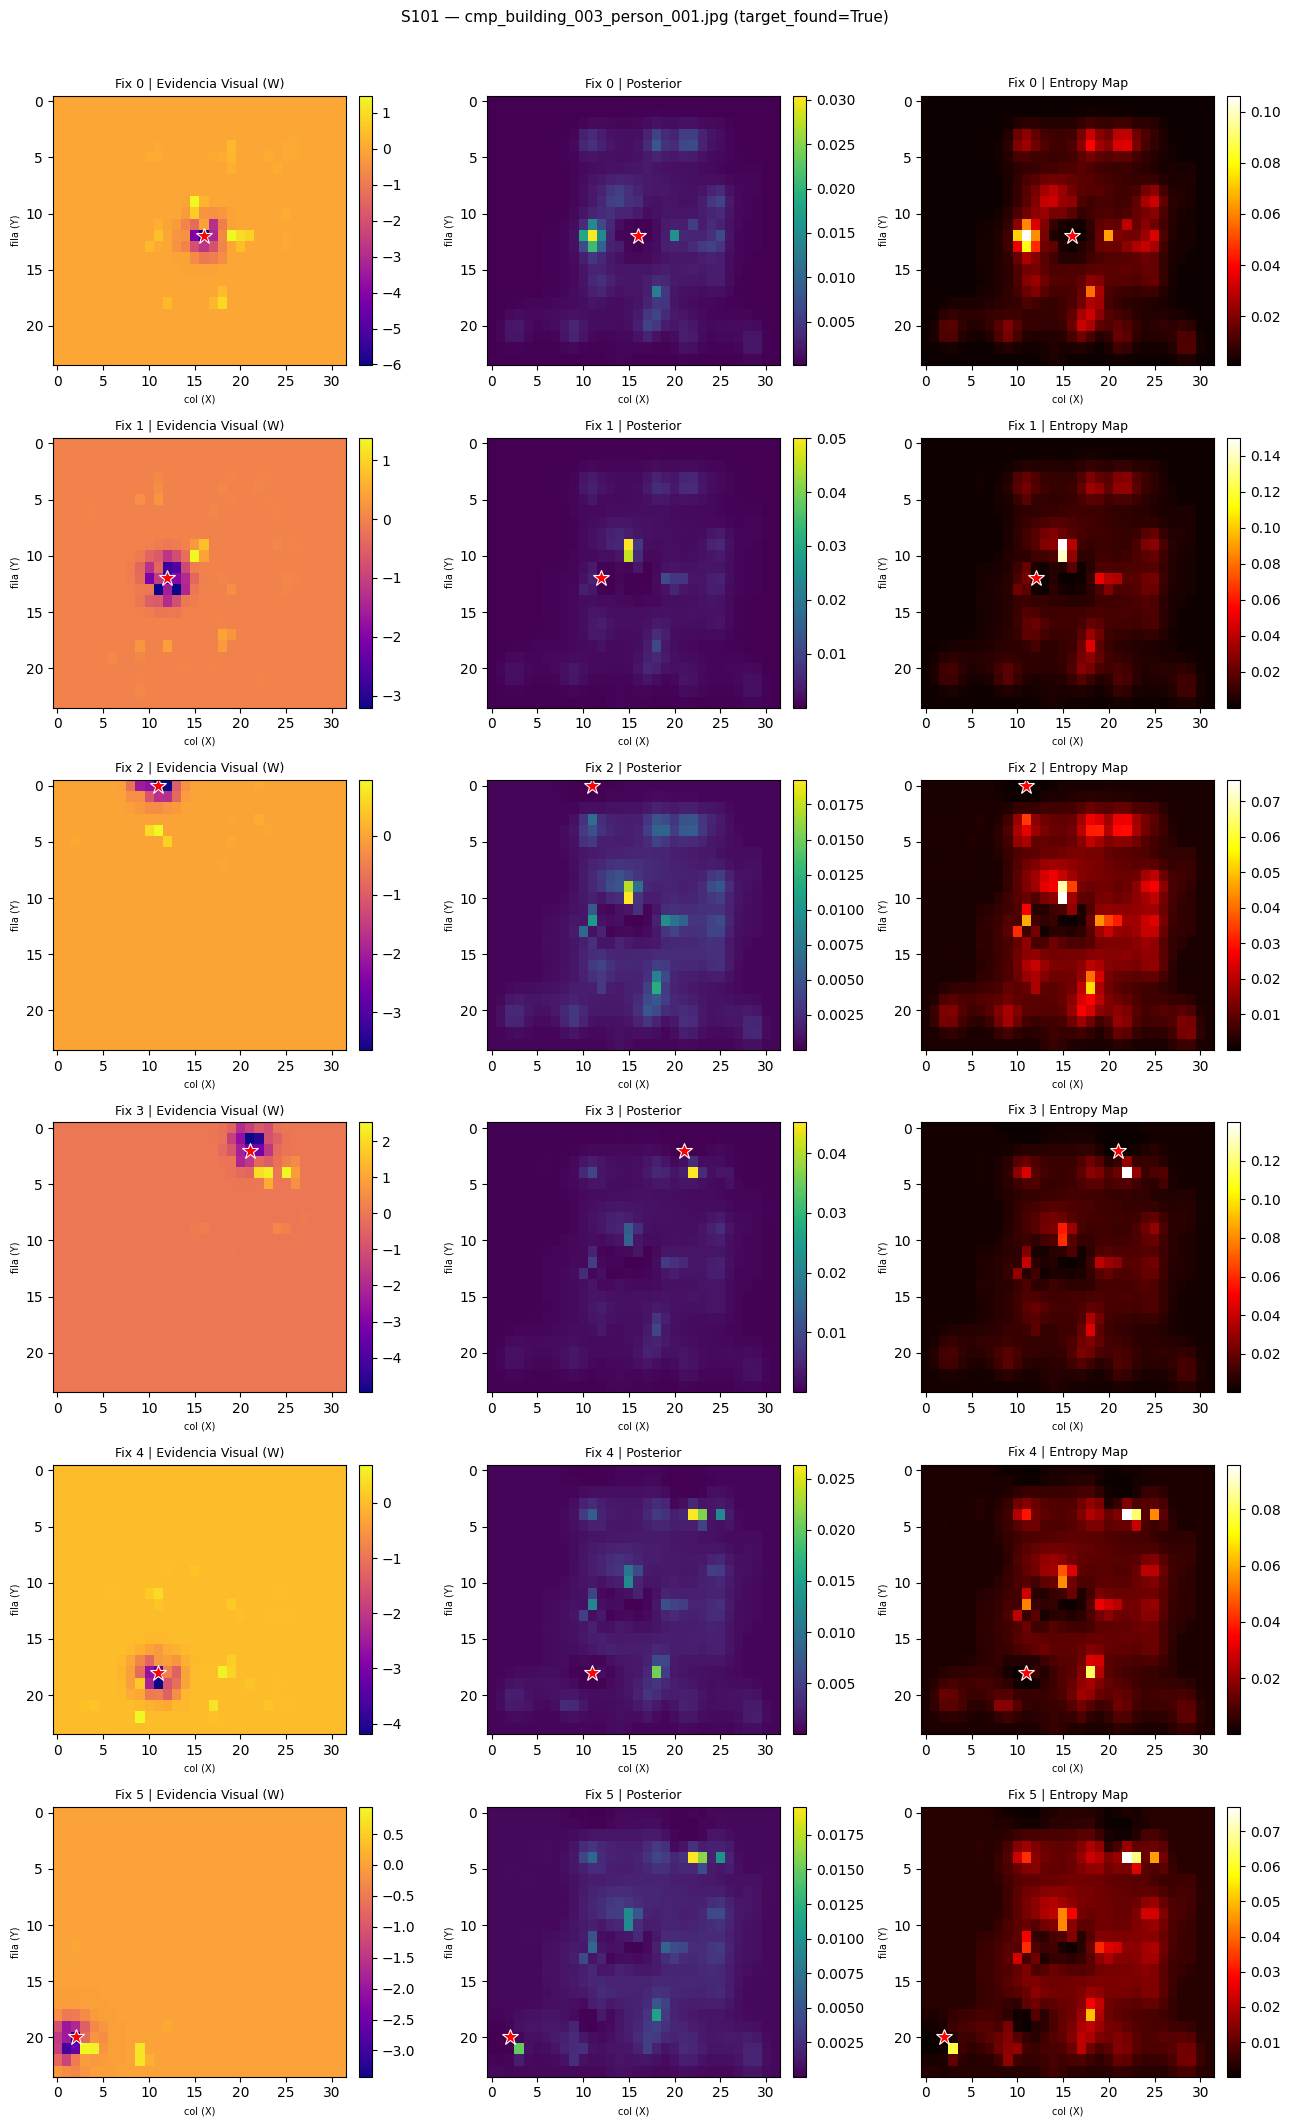

In [19]:
def graficar_secuencia_fijaciones(data, titulo='', n_max=6):
    """
    Grilla: filas = fijaciones, columnas = [visual_evidence, posterior, entropy_map, expected_ig_map].
    El marcador rojo indica la posición de fijación en la grilla.
    """
    n_fix  = data['posterior'].shape[0]
    n_rows = min(n_fix, n_max)
    campos = [
        ('Evidencia Visual (W)', data['visual_evidence'], 'plasma'),
        ('Posterior',            data['posterior'],       'viridis'),
        ('Entropy Map',          data['entropy_map'],     'hot'),
        ('Expected IG Map',      data['expected_ig_map'], 'cividis'),
    ]
    n_cols = len(campos)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.5 * n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    for row in range(n_rows):
        fy, fx = int(data['fixations_y'][row]), int(data['fixations_x'][row])
        for col, (nombre, mapa, cmap) in enumerate(campos):
            ax = axes[row, col]
            if mapa is not None:
                im = ax.imshow(mapa[row], cmap=cmap, aspect='auto')
                plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            else:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center')
            # Marcar posición de fijación
            ax.plot(fx, fy, 'r*', markersize=12, markeredgecolor='white', markeredgewidth=0.8)
            ax.set_title(f'Fix {row} | {nombre}', fontsize=9)
            ax.set_xlabel('col (X)', fontsize=7)
            ax.set_ylabel('fila (Y)', fontsize=7)

    plt.suptitle(titulo, fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()


graficar_secuencia_fijaciones(
    data_ej,
    titulo=f'{SUJETO_EJEMPLO} — {IMAGEN} (target_found={data_ej["target_found"]})',
    n_max=6
)

---
## 5. Análisis Temporal

Cómo evolucionan las métricas a lo largo del scanpath.

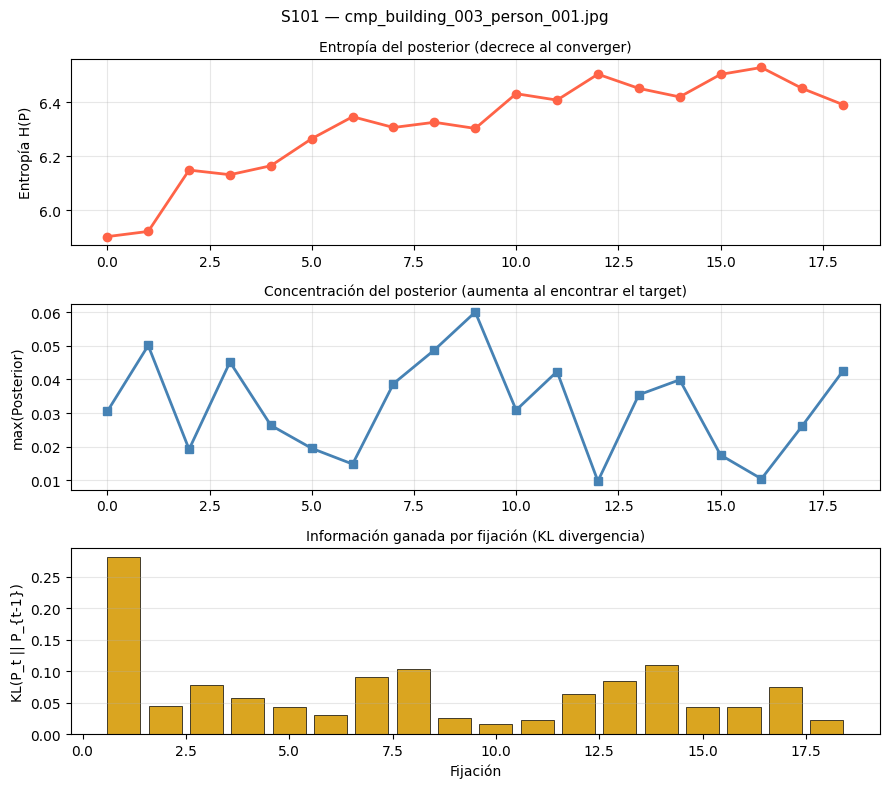

In [20]:
def graficar_evolucion_temporal(data, titulo=''):
    """Entropía escalar, concentración del posterior, KL consecutivo y EIG por fijación."""
    entropia = ml.entropia_escalar(data)
    conc     = ml.concentracion_posterior(data)
    kl       = ml.kl_divergencia_consecutiva(data)
    eig_fix  = ml.eig_en_fijacion(data)
    eig_max  = ml.eig_maximo(data)
    n        = len(entropia)
    tiene_eig = len(eig_fix) == n

    n_panels = 4 if tiene_eig else 3
    fig, axes = plt.subplots(n_panels, 1, figsize=(9, 3 * n_panels), sharex=False)

    # 1. Entropía
    axes[0].plot(range(n), entropia, 'o-', color='tomato', linewidth=2)
    axes[0].set_ylabel('Entropía H(P)', fontsize=10)
    axes[0].set_title('Entropía del posterior (decrece al converger)', fontsize=10)
    axes[0].grid(True, alpha=0.3)

    # 2. Concentración (max posterior)
    axes[1].plot(range(n), conc, 's-', color='steelblue', linewidth=2)
    axes[1].set_ylabel('max(Posterior)', fontsize=10)
    axes[1].set_title('Concentración del posterior (aumenta al encontrar el target)', fontsize=10)
    axes[1].grid(True, alpha=0.3)

    # 3. KL consecutivo
    axes[2].bar(range(1, n), kl, color='goldenrod', edgecolor='k', linewidth=0.5)
    axes[2].set_xlabel('Fijación', fontsize=10)
    axes[2].set_ylabel('KL(P_t || P_{t-1})', fontsize=10)
    axes[2].set_title('Información ganada por fijación (KL divergencia)', fontsize=10)
    axes[2].grid(True, alpha=0.3, axis='y')

    # 4. EIG (solo si disponible en el archivo)
    if tiene_eig:
        axes[3].plot(range(n), eig_fix, 'D-', color='mediumseagreen', linewidth=2,
                     label='EIG en fijación humana')
        axes[3].plot(range(n), eig_max, '--', color='gray', linewidth=1.5,
                     label='EIG máximo (sácada óptima)')
        axes[3].fill_between(range(n), eig_fix, eig_max, alpha=0.15, color='mediumseagreen')
        axes[3].set_xlabel('Fijación', fontsize=10)
        axes[3].set_ylabel('EIG', fontsize=10)
        axes[3].set_title('Expected IG — fijación humana vs. óptimo del modelo', fontsize=10)
        axes[3].legend(fontsize=9)
        axes[3].grid(True, alpha=0.3)
    else:
        axes[-1].set_xlabel('Fijación', fontsize=10)

    plt.suptitle(titulo, fontsize=11)
    plt.tight_layout()
    plt.show()


graficar_evolucion_temporal(
    data_ej,
    titulo=f'{SUJETO_EJEMPLO} — {IMAGEN}'
)

In [21]:
# Verificar que la entropía generalmente decrece (como se espera en un modelo bayesiano)
# Analizar sobre N trials aleatorios del sujeto ejemplo

N_TRIALS = min(20, len(imagenes))
muestras = random.sample(imagenes, N_TRIALS)

monotona_decrece = 0
for img in muestras:
    try:
        d = ml.cargar_mapas_humanos(SUJETO_EJEMPLO, img)
        ent = ml.entropia_escalar(d)
        if len(ent) > 1 and ent[-1] < ent[0]:
            monotona_decrece += 1
    except Exception:
        pass

print(f'Trials donde la entropía final < inicial: {monotona_decrece}/{N_TRIALS} '
      f'({100*monotona_decrece/N_TRIALS:.0f}%)')
print('(Esperado: mayoría — el modelo reduce incertidumbre al ver más fijaciones)')

Trials donde la entropía final < inicial: 7/20 (35%)
(Esperado: mayoría — el modelo reduce incertidumbre al ver más fijaciones)


---
## 6. Análisis Multi-Sujeto

Para la misma imagen, comparar la evolución de entropía entre sujetos.

In [22]:
IMAGEN_MS = IMAGEN   # Misma imagen usada como ejemplo arriba

# Sujetos que tienen datos para esta imagen
sujetos_con_img = [s for s in sujetos if (ml.PATHS['human_maps'] / s / (IMAGEN[:-4] + '.npz')).exists()]
print(f'Sujetos con datos para {IMAGEN_MS}: {len(sujetos_con_img)}')

# Cargar entropías
entropias_ms = {}
for s in sujetos_con_img:
    try:
        d = ml.cargar_mapas_humanos(s, IMAGEN_MS)
        entropias_ms[s] = ml.entropia_escalar(d)
    except Exception:
        pass

print(f'Cargados: {len(entropias_ms)} sujetos')

Sujetos con datos para cmp_building_003_person_001.jpg: 42
Cargados: 42 sujetos


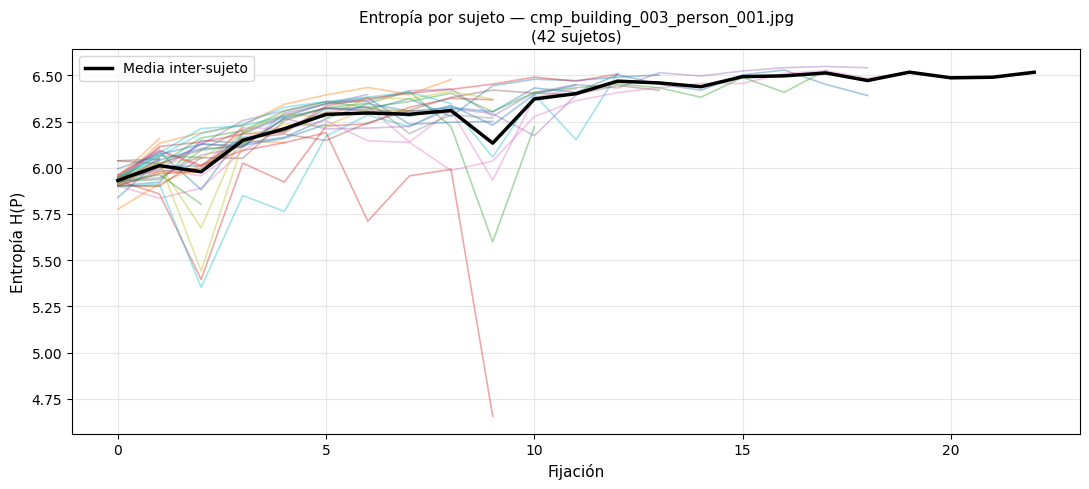

In [23]:
fig, ax = plt.subplots(figsize=(11, 5))

for subj, ent in entropias_ms.items():
    ax.plot(range(len(ent)), ent, alpha=0.4, linewidth=1.2)

# Media inter-sujeto en cada posición de fijación
max_len = max(len(e) for e in entropias_ms.values())
medias  = [np.nanmean([e[i] for e in entropias_ms.values() if i < len(e)])
           for i in range(max_len)]
ax.plot(range(max_len), medias, 'k-', linewidth=2.5, label='Media inter-sujeto', zorder=5)

ax.set_xlabel('Fijación', fontsize=11)
ax.set_ylabel('Entropía H(P)', fontsize=11)
ax.set_title(f'Entropía por sujeto — {IMAGEN_MS}\n({len(entropias_ms)} sujetos)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

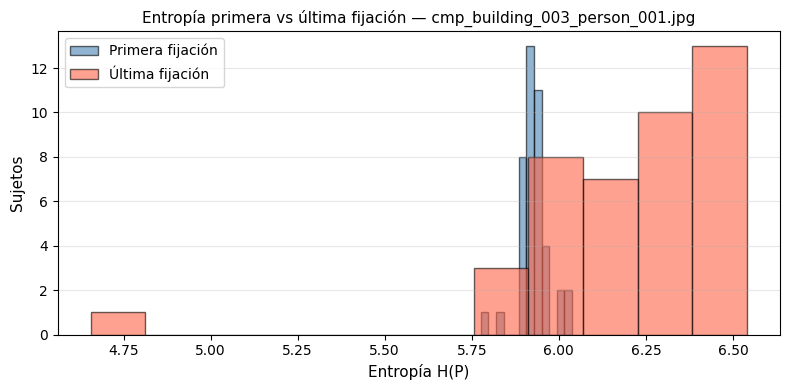

Entropía inicial: media=5.931, std=0.044
Entropía final:   media=6.209, std=0.310


In [24]:
# Distribución de entropía: primera vs última fijación (todos los sujetos, esta imagen)
entropias_ini = [e[0]  for e in entropias_ms.values() if len(e) > 0]
entropias_fin = [e[-1] for e in entropias_ms.values() if len(e) > 0]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(entropias_ini, bins=12, alpha=0.6, label='Primera fijación', color='steelblue', edgecolor='k')
ax.hist(entropias_fin, bins=12, alpha=0.6, label='Última fijación',  color='tomato',    edgecolor='k')
ax.set_xlabel('Entropía H(P)', fontsize=11)
ax.set_ylabel('Sujetos', fontsize=11)
ax.set_title(f'Entropía primera vs última fijación — {IMAGEN_MS}', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f'Entropía inicial: media={np.mean(entropias_ini):.3f}, std={np.std(entropias_ini):.3f}')
print(f'Entropía final:   media={np.mean(entropias_fin):.3f}, std={np.std(entropias_fin):.3f}')

---
## 7. Preview de Features para EEG

Extracción de los valores puntuales en cada fijación humana.
Esta tabla será el punto de partida para el modelo de deconvolución.

In [25]:
# Tabla de features por fijación para el trial de ejemplo
df_features = ml.tabla_features_fijacion(data_ej, IMAGEN)

# Agregar features de mapas estáticos (valor en la celda de fijación)
sal_grid = ml.cargar_mapa_saliencia(IMAGEN, como_grilla=True)
df_features['saliencia_at_fix'] = ml.valor_en_fijacion(sal_grid, data_ej)

if ml.mapa_similitud_existe(IMAGEN, TARGET):
    sim_grid = ml.cargar_mapa_similitud(IMAGEN, TARGET, como_grilla=True)
    df_features['similitud_at_fix'] = ml.valor_en_fijacion(sim_grid, data_ej)

print(f'Trial: {SUJETO_EJEMPLO} | {IMAGEN} | target_found={data_ej["target_found"]}')
display(df_features.round(4))

Trial: S101 | cmp_building_003_person_001.jpg | target_found=True


,fixation,fix_y,fix_x,entropy,kl_prev,max_posterior,ve_at_fix,post_at_fix,saliencia_at_fix,similitud_at_fix
0,0,12,16,5.9026,NaN,0.0305,-6.0208,0.0001,0.0588,0.0314
1,1,12,12,5.9218,0.2813,0.0501,-2.7044,0.0003,0.3451,0.1686
2,2,0,11,6.1488,0.0445,0.0192,-3.6361,0.0000,0.0000,0.0000
3,3,2,21,6.1317,0.0786,0.0452,-3.3767,0.0001,0.0157,0.0078
4,4,18,11,6.1648,0.0577,0.0264,-3.2715,0.0002,0.0196,0.2863
5,5,20,2,6.2650,0.0425,0.0195,-3.4255,0.0000,0.0353,0.0392
6,6,20,3,6.3463,0.0298,0.0148,-2.9540,0.0000,0.0353,0.0784
7,7,19,19,6.3064,0.0910,0.0387,-2.3149,0.0001,0.0667,0.0824
8,8,19,18,6.3257,0.1033,0.0487,-4.9155,0.0001,0.1255,0.1765
9,9,19,28,6.3029,0.0258,0.0600,-2.1540,0.0000,0.0039,0.1373


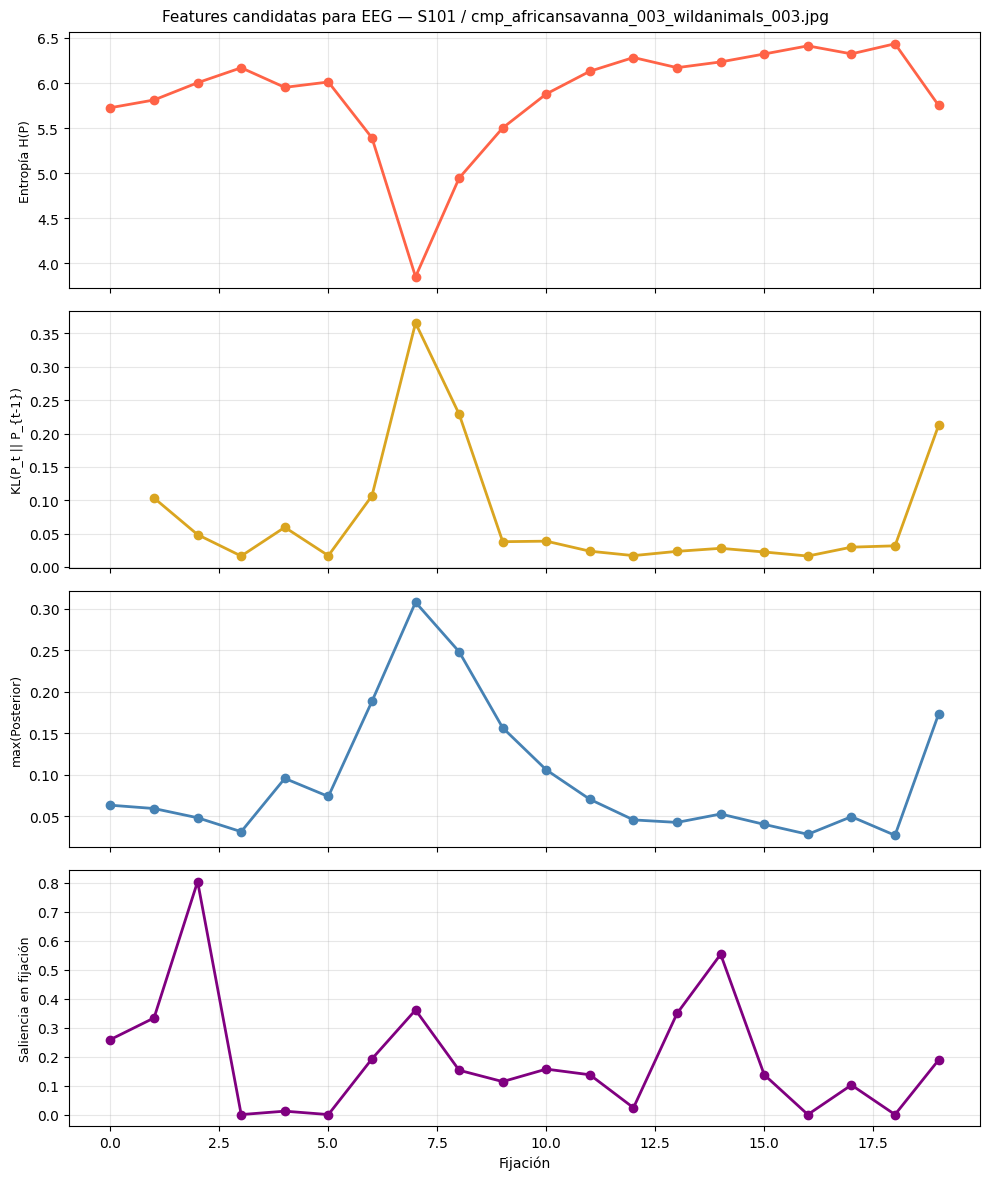

In [18]:
# Visualizar las features candidatas para EEG a lo largo del scanpath
features_a_graficar = [
    ('entropy',          'Entropía H(P)',                  'tomato'),
    ('kl_prev',          'KL(P_t || P_{t-1})',             'goldenrod'),
    ('max_posterior',    'max(Posterior)',                  'steelblue'),
    ('eig_at_fix',       'EIG en fijación humana',          'mediumseagreen'),
    ('eig_max',          'EIG máximo (sácada óptima)',      'gray'),
    ('saliencia_at_fix', 'Saliencia en fijación',          'purple'),
]

n_plots = len(features_a_graficar)
fig, axes = plt.subplots(n_plots, 1, figsize=(10, 3 * n_plots), sharex=True)

for ax, (col, label, color) in zip(axes, features_a_graficar):
    if col in df_features.columns and not df_features[col].isna().all():
        vals = df_features[col].values
        xs   = df_features['fixation'].values
        ax.plot(xs, vals, 'o-', color=color, linewidth=2)
        ax.set_ylabel(label, fontsize=9)
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, f'{col} no disponible', ha='center', va='center',
                transform=ax.transAxes)

axes[-1].set_xlabel('Fijación', fontsize=10)
plt.suptitle(f'Features candidatas para EEG — {SUJETO_EJEMPLO} / {IMAGEN}', fontsize=11)
plt.tight_layout()
plt.show()

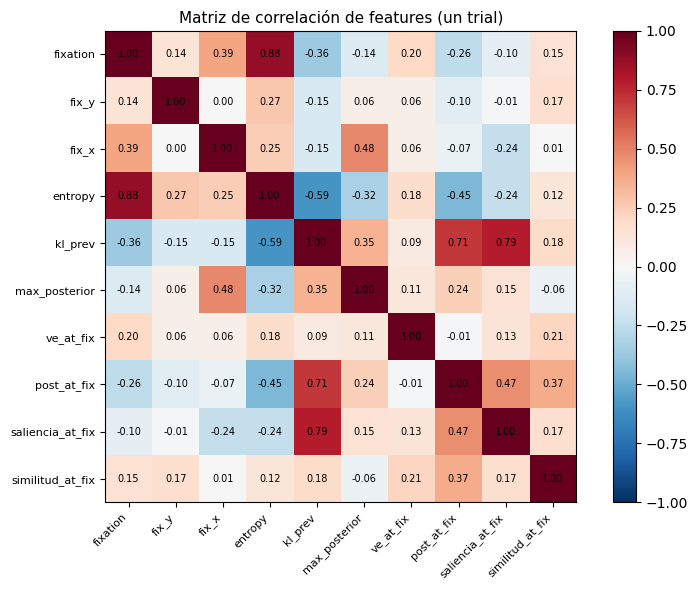

In [26]:
# Correlación entre features (para chequear colinealidad antes del EEG)
cols_numericas = [c for c in df_features.columns if df_features[c].dtype != object]
corr = df_features[cols_numericas].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center', fontsize=7)
ax.set_title('Matriz de correlación de features (un trial)', fontsize=11)
plt.tight_layout()
plt.show()